percentage: 27.36%


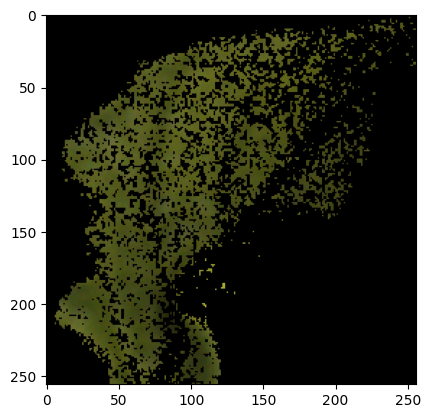

percentage: 29.29%


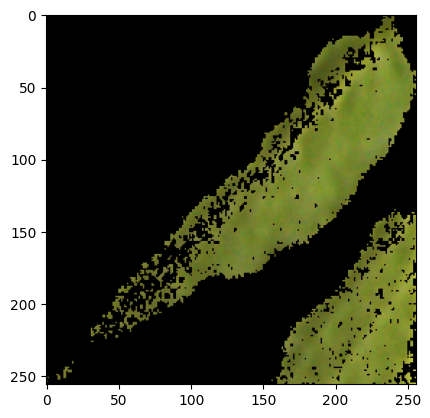

percentage: 23.59%


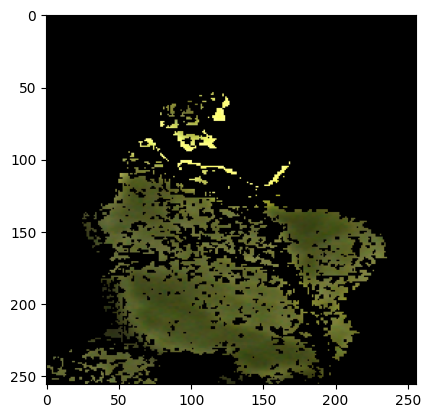

percentage: 27.53%


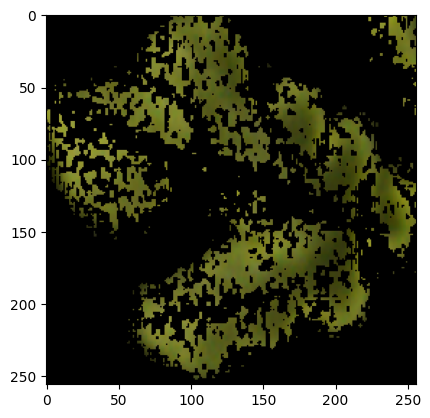

percentage: 21.26%


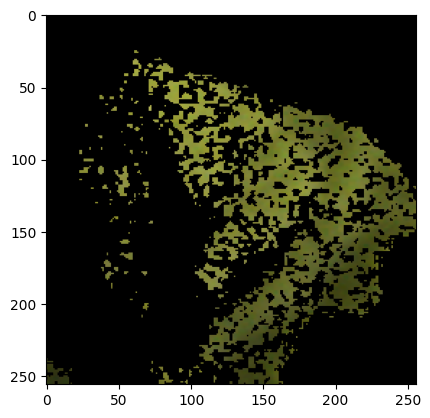

percentage: 29.81%


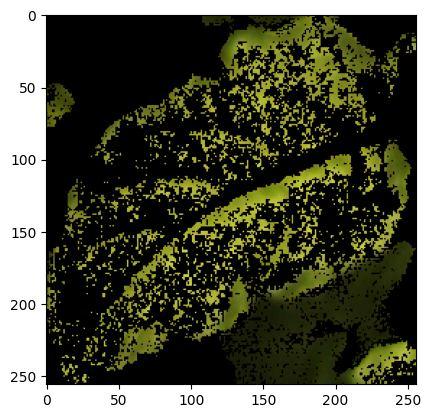

percentage: 22.40%


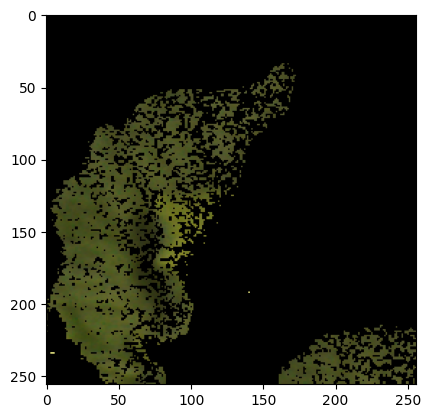

percentage: 22.61%


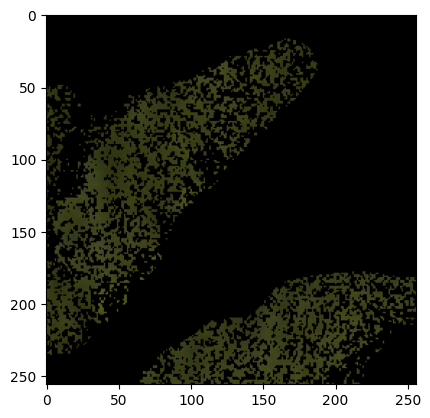

Loaded 2258 images for class 0
Loaded 1390 images for class 1


In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

img_dir = '../Croptimal/resnet/train'

class_subdirs = [
    # Class 0
    # (subdir, weight)
    [('256_class_0', 1.0)],
    # Class 1
    [('256_class_1', 1.0)]]

n_classes = len(class_subdirs)
global_imgs = []

hue=[30, 50]
saturation=[110, 240]

for i, class_data in enumerate(class_subdirs):
    global_imgs.append([])
    for subdir, weight in class_data:
        class_path = os.path.join(img_dir, subdir)
        for img_file in os.listdir(class_path):
            if img_file.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
                mask = (
                    (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
                    (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
                )
                img = img * mask[..., None]
                # if mask.sum() < 0.3 * mask.size:
                #     print(f'percentage: {100 * mask.sum() / mask.size:.2f}%')
                #     plt.imshow(img)
                #     plt.show()
                if img is not None:
                    global_imgs[i].append(img)

for i in range(n_classes):
    print(f'Loaded {len(global_imgs[i])} images for class {i}')

import random

dataset = []
for label in range(n_classes):
    for img in global_imgs[label]:
        dataset.append((img, label))

random.shuffle(dataset)

In [2]:
import os
import cv2
import numpy as np

def load_images_from_dir(path):
    images = []
    for fname in os.listdir(path):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            img = cv2.imread(os.path.join(path, fname))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
            mask = (
                (hsv[:, :, 0] >= hue[0]) & (hsv[:, :, 0] <= hue[1]) &
                (hsv[:, :, 1] >= saturation[0]) & (hsv[:, :, 1] <= saturation[1])
            )
            img = img * mask[..., None]
            images.append(img)
    return images

val_imgs = {
    0: load_images_from_dir("../Croptimal/resnet/val/256_class_0"),
    1: load_images_from_dir("../Croptimal/resnet/val/256_class_1"),
}

import torch

def image_to_pixels(img, samples, features=3):
    img_tensor = torch.from_numpy(img).float() / 255.0
    img_flat = img_tensor.reshape(-1, features)

    if samples < img_flat.shape[0]:
        idx = torch.randperm(img_flat.shape[0])[:samples]
        img_flat = img_flat[idx]

    return img_flat

def predict_image(model, img, samples=2048):
    pixels = image_to_pixels(img, samples)

    with torch.no_grad():
        preds = model.inference(pixels)

    return torch.mode(preds).values.item()

def evaluate(model, val_imgs, samples=2048):
    TP = FP = TN = FN = 0

    for true_label, imgs in val_imgs.items():
        for img in imgs:
            pred = predict_image(model, img, samples)

            if true_label == 1:
                if pred == 1:
                    TP += 1
                else:
                    FN += 1
            else:  # true_label == 0
                if pred == 1:
                    FP += 1
                else:
                    TN += 1

    accuracy = (TP + TN) / max(TP + TN + FP + FN, 1)
    fpr = FP / max(FP + TN, 1)
    fnr = FN / max(FN + TP, 1)

    return {
        "accuracy": accuracy,
        "false_positive_rate": fpr,
        "false_negative_rate": fnr,
        "TP": TP,
        "FP": FP,
        "TN": TN,
        "FN": FN,
    }

100%|██████████| 3648/3648 [00:41<00:00, 88.00it/s] 


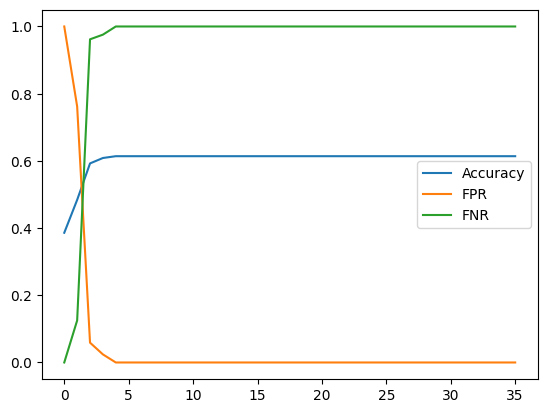

In [13]:
import sys

from tqdm import tqdm
import matplotlib.pyplot as plt
sys.path.insert(0, 'leaves-2025-07-03')
from gmlvq import gmlvq
import torch

lvq = gmlvq()
features = 3 # RGB channels
prototypes_per_class = 5
prototype_labels = [0, 1] * prototypes_per_class
initial_prototypes = torch.randn(n_classes * prototypes_per_class, features)
mu = torch.randn(features)
std = torch.randn(features) + 0.1
lvq.initialize(features, initial_prototypes, prototype_labels, True, mu, std)

def trainImage(img, model, samples, label):
    img_tensor = torch.from_numpy(img).float() / 255.0
    img_flat = img_tensor.reshape(-1, features)
    #remove black pixels
    img_flat = img_flat[~torch.all(img_flat == 0, dim=1)]

    indices = torch.randperm(img_flat.shape[0])[:samples]
    sampled_pixels = img_flat[indices]

    labels = torch.full((samples,), label, dtype=torch.long)

    loss = model.train(sampled_pixels, labels)
    return loss


samples = 50
# n_minibatches = 250
losses = []
accuracies = []
# lvq.freeze_metric()
for i, (img, label) in enumerate(tqdm(dataset)):
    # if i == 50:
    #     lvq.unfreeze_metric()
    losses.append(trainImage(img, lvq, samples, label).data)
    if i % 100 == 0 and i > 0:
        accuracies.append(evaluate(lvq, val_imgs, samples=2048))

# plt.plot(losses)
plt.plot([acc['accuracy'] for acc in accuracies], label='Accuracy')
plt.plot([acc['false_positive_rate'] for acc in accuracies], label='FPR')
plt.plot([acc['false_negative_rate'] for acc in accuracies], label='FNR')
plt.legend()
# plt.ylim(0,1)


In [4]:
metrics = evaluate(lvq, val_imgs, samples=2048)

print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"FPR:      {metrics['false_positive_rate']:.4f}")
print(f"FNR:      {metrics['false_negative_rate']:.4f}")

Accuracy: 0.6139
FPR:      0.0000
FNR:      1.0000
